In [1]:
# load master dataset
import pandas as pd
import numpy as np

df = pd.read_csv('data/processed/master_dataset_merged.csv')

# Quick check: How many rows and columns?
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")

Dataset shape: (276, 20)

Column names: ['race_number', 'race_name', 'race_date', 'primary_sponsor', 'finish_position', 'laps_led', 'merge_key', 'reddit_mention_count', 'youtube_total_view_count', 'youtube_total_like_count', 'youtube_total_comment_count', 'youtube_total_duration_seconds', 'num_youtube_videos', 'news_total_mentions', 'news_weighted_mentions', 'news_passing_mentions', 'news_primary_mentions', 'news_secondary_mentions', 'driver_search_interest', 'sponsor_search_interest']


In [ ]:
# Keep only the 5 tracked sponsors — each already maps to exactly one car per
# race in the source data, so this gives one clean datapoint per car, no
# aggregation needed. "Other/Unknown" pools ~35 unrelated cars per race behind
# a single row (finish_position taken via min/mean), which distorts any metric
# built from it — drop it rather than aggregate it.
df = df[df['primary_sponsor'] != 'Other/Unknown'].reset_index(drop=True)

print(f"Dataset shape after dropping Other/Unknown: {df.shape}")
print(df['primary_sponsor'].value_counts())

Dataset shape after dropping Other/Unknown: (223, 20)
primary_sponsor
Busch Light                  53
Castrol                      53
Love's Travel Stops          53
Progressive                  52
Cheddar's Scratch Kitchen    12
Name: count, dtype: int64


## Distribution check: predictor histograms

Before fitting anything, look at the shape of each candidate predictor. A histogram
answers three questions at a glance: is it skewed (candidate for a log transform),
is it zero-inflated (candidate for a two-part model), and does it have extreme
outliers (candidate for winsorizing). We build one reusable plotting function so
every panel is visually consistent, then run it across all numeric predictors.

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

# --- design tokens (single sequential hue + recessive chrome) ---
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
FILL = "#86b6ef"      # sequential step 250 (fill)
FILL_EDGE = "#2a78d6" # sequential step 450 (edge / mean line)
SURFACE = "#fcfcfb"

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Segoe UI", "Helvetica Neue", "Arial", "sans-serif"]


def plot_histogram(data: pd.DataFrame, column: str, ax=None, bins=30, log=False):
    """One consistently-styled histogram panel for a single numeric predictor."""
    series = data[column].dropna()
    values = np.log1p(series) if log else series

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3.2), dpi=150)

    ax.set_facecolor(SURFACE)
    ax.hist(values, bins=bins, color=FILL, edgecolor=SURFACE, linewidth=0.5, zorder=2)

    mean_val, median_val = values.mean(), values.median()
    ax.axvline(mean_val, color=FILL_EDGE, linewidth=1.5, zorder=3)
    ax.axvline(median_val, color=INK_SECONDARY, linewidth=1, linestyle="--", zorder=3)

    ymax = ax.get_ylim()[1]
    ax.text(mean_val, ymax * 1.02, "mean", color=FILL_EDGE, fontsize=8,
            ha="center", va="bottom")
    ax.text(median_val, ymax * 1.14, "median", color=INK_SECONDARY, fontsize=8,
            ha="center", va="bottom")

    # skew + normality read, annotated directly rather than left to the eye
    skew = stats.skew(series)
    if 3 <= len(series) <= 5000:
        _, p = stats.shapiro(series)
        stat_label = f"skew={skew:.2f}  |  Shapiro–Wilk p={p:.3f}"
    else:
        stat_label = f"skew={skew:.2f}"
   
    ax.text(0.02, 0.96, stat_label, transform=ax.transAxes, fontsize=7.5,
            color=INK_MUTED, ha="left", va="top")

    title = column.replace("_", " ")
    if log:
        title += "  (log1p)"
    ax.set_title(title, fontsize=10, color=INK_PRIMARY, loc="left", pad=8)

    ax.grid(axis="y", color=GRIDLINE, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)
    ax.tick_params(axis="both", colors=INK_MUTED, labelsize=8, length=0)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=4))

    return ax

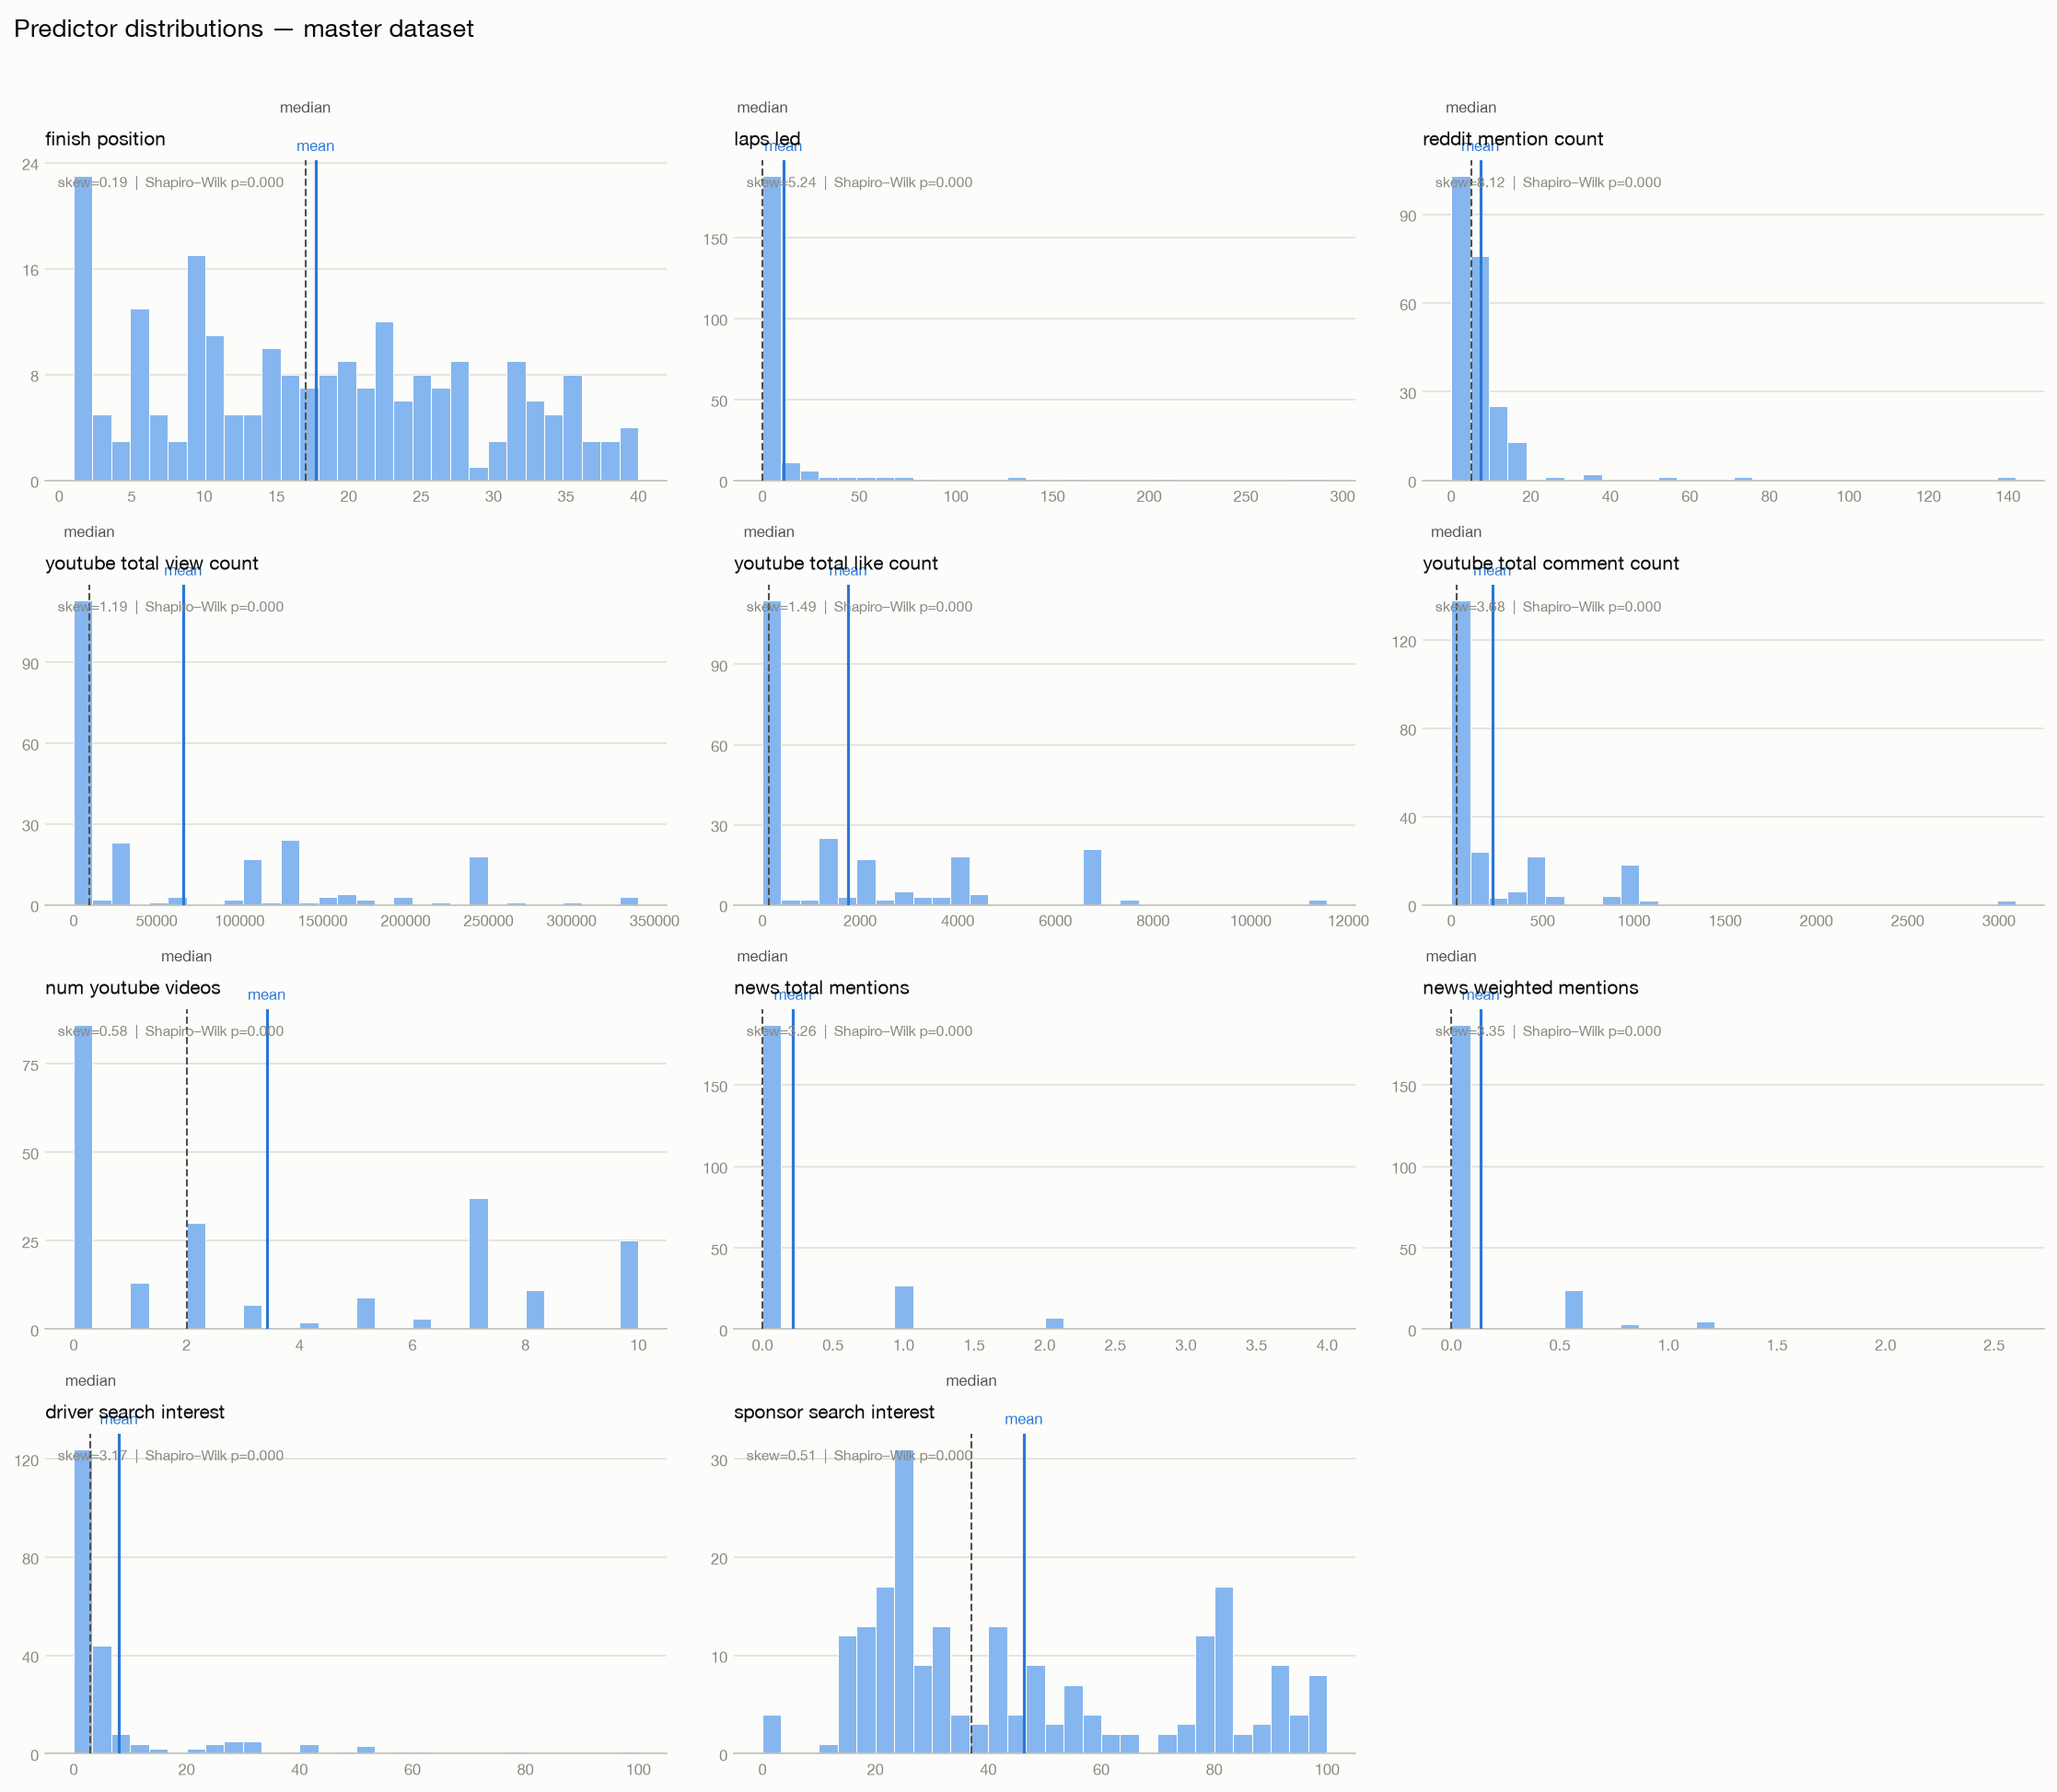

In [ ]:
predictor_cols = [
    "finish_position", "laps_led", "reddit_mention_count",
    "youtube_total_view_count", "youtube_total_like_count",
    "youtube_total_comment_count", "num_youtube_videos",
    "news_total_mentions", "news_weighted_mentions",
    "driver_search_interest", "sponsor_search_interest",
]

n_cols = 3
n_rows = int(np.ceil(len(predictor_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.2 * n_rows), dpi=150)
fig.patch.set_facecolor(SURFACE)
axes = axes.flatten()

for ax, col in zip(axes, predictor_cols):
    plot_histogram(df, col, ax=ax)

for ax in axes[len(predictor_cols):]:
    ax.axis("off")

fig.suptitle("Predictor distributions — master dataset", fontsize=13,
             color=INK_PRIMARY, x=0.01, ha="left", y=1.01)
fig.tight_layout()
plt.show()

In [5]:
# Group by sponsor and calculate key statistics
performance_stats = df.groupby('primary_sponsor').agg({
    'finish_position': ['mean', 'median', 'std', 'min', 'max'],
    'laps_led': ['sum', 'mean'],
}).round(2)

# Flatten column names for readability
performance_stats.columns = ['_'.join(col) for col in performance_stats.columns]
performance_stats = performance_stats.reset_index()

print("Performance Statistics by Sponsor:")
print(performance_stats)

Performance Statistics by Sponsor:
             primary_sponsor  finish_position_mean  finish_position_median  \
0                Busch Light                 17.23                    16.0   
1                    Castrol                 18.81                    16.0   
2  Cheddar's Scratch Kitchen                 24.92                    26.0   
3        Love's Travel Stops                 20.96                    21.0   
4                Progressive                 12.08                     8.0   

   finish_position_std  finish_position_min  finish_position_max  \
0                10.39                    1                   40   
1                11.54                    2                   39   
2                 7.44                    9                   36   
3                 8.63                    2                   39   
4                11.37                    1                   38   

   laps_led_sum  laps_led_mean  
0           143           2.70  
1           382      

In [6]:
# Exposure statistics by sponsor
exposure_stats = df.groupby('primary_sponsor').agg({
    'reddit_mention_count': ['sum', 'mean', 'std','median'],
    'youtube_total_view_count': ['sum', 'mean','std','median'],
    'news_total_mentions': ['sum', 'mean'],
    'youtube_total_like_count': ['sum','mean','std','median'],
    'youtube_total_comment_count': ['sum','mean', 'std', 'median'],
    'news_weighted_mentions': ['sum','mean'],
    'driver_search_interest': ['mean','std'],
    'sponsor_search_interest': ['mean','std']
}).round(2)

exposure_stats.columns = ['_'.join(col) for col in exposure_stats.columns]
exposure_stats = exposure_stats.reset_index()

print("\nExposure Statistics by Sponsor:")
print(exposure_stats)


Exposure Statistics by Sponsor:
             primary_sponsor  reddit_mention_count_sum  \
0                Busch Light                     347.0   
1                    Castrol                     344.0   
2  Cheddar's Scratch Kitchen                      64.0   
3        Love's Travel Stops                     161.0   
4                Progressive                     708.0   

   reddit_mention_count_mean  reddit_mention_count_std  \
0                       6.55                      7.02   
1                       6.49                      9.41   
2                       5.33                      4.29   
3                       3.04                      4.95   
4                      13.62                     18.99   

   reddit_mention_count_median  youtube_total_view_count_sum  \
0                          6.0                     2848128.0   
1                          5.0                     3333140.0   
2                          4.0                      724647.0   
3            

In [7]:
race_df = pd.read_csv('data/processed/race_results_standardized.csv')
reddit_df = pd.read_csv('data/processed/reddit_mentions_standardized.csv')
youtube_df = pd.read_csv('data/processed/youtube_engagement_standardized.csv')
news_df = pd.read_csv('data/processed/news_mentions_standardized.csv')

# Create race-level summary from race results
# (Each row = one sponsor at one race)
race_mean = race_df.groupby(['race_number', 'race_name', 'race_date', 'primary_sponsor']).agg({
    'finish_position': 'mean',  # Best finish among cars carrying that sponsor
    'laps_led': 'mean'  # Total laps led by cars carrying that sponsor
}).reset_index()

In [10]:
# For each sponsor, find their highest and lowest exposure races per metric
metric_cols = {
    'reddit': 'reddit_mention_count',
    'news': 'news_total_mentions',
    'yt': 'youtube_total_view_count',
}

for sponsor in df['primary_sponsor'].unique():
    sponsor_data = df[df['primary_sponsor'] == sponsor]
    print(f"\n{sponsor}:")

    for metric, col in metric_cols.items():
        highest = sponsor_data.loc[sponsor_data[col].idxmax()]
        lowest = sponsor_data.loc[sponsor_data[col].idxmin()]

        print(f"  Highest {metric} exposure: {highest['race_name']} (Finished P{highest['finish_position']:.0f})")
        print(f"  Lowest {metric} exposure: {lowest['race_name']} (Finished P{lowest['finish_position']:.0f})")


Busch Light:
  Highest reddit exposure: 2025 Cup Series Championship (Finished P13)
  Lowest reddit exposure: 2025 South Point 400 (Finished P23)
  Highest news exposure: 2025 AdventHealth 400 (Finished P18)
  Lowest news exposure: 2025 Ambetter Health 400 (Finished P8)
  Highest yt exposure: 2025 Viva Mexico 250 (Finished P16)
  Lowest yt exposure: 2025 Iowa Corn 350 (Finished P11)

Castrol:
  Highest reddit exposure: 2025 Cup Series Championship (Finished P2)
  Lowest reddit exposure: 2025 Straight Talk Wireless 400 (Finished P26)
  Highest news exposure: 2026 Daytona 500 (Finished P5)
  Lowest news exposure: 2025 Daytona 500 (Finished P26)
  Highest yt exposure: 2025 Cook Out 400 (Finished P26)
  Lowest yt exposure: 2025 Toyota Save Mart 350 (Finished P11)

Love's Travel Stops:
  Highest reddit exposure: 2025 Cup Series Championship (Finished P22)
  Lowest reddit exposure: 2025 Ambetter Health 400 (Finished P15)
  Highest news exposure: 2025 South Point 400 (Finished P21)
  Lowest 

In [15]:
# Merge performance and exposure statistics
summary_stats = pd.merge(performance_stats, exposure_stats, on='primary_sponsor')

# Add calculated fields
summary_stats['Top_5_Rate'] = df.groupby('primary_sponsor').apply(
    lambda x: (x['finish_position'] <= 5).mean() * 100
).values.round(1)

summary_stats['Win_Count'] = df.groupby('primary_sponsor').apply(
    lambda x: (x['finish_position'] == 1).sum()
).values

# Save to CSV for later reference
summary_stats.to_csv('data/processed/sponsor_summary_statistics.csv', index=False)
print("\nSummary saved to sponsor_summary_statistics.csv")


Summary saved to sponsor_summary_statistics.csv


In [18]:
#  Pearson Correlation:
# assumptions:
# Both variables are continuous
# The relationship is linear (not curved)
# No significant outliers (they can distort the correlation)
# Data is roughly normally distributed

# by observation from our histograms, along with shapiro wilkes test, we know the data is not
# normally distributed, we also saw there are numerous outliers

# I will use Spearman correlation:

from scipy import stats

# Create a correlation matrix for key variables
# Note: We'll invert finish position so higher = better for intuitive reading
df['Finish_Position_Inverted'] = df['finish_position'].max() - df['finish_position'] + 1

correlation_vars = [
    'finish_position',
    'laps_led',
    'reddit_mention_count',
    'youtube_total_view_count',
    'youtube_total_like_count',
    'youtube_total_comment_count',
    'news_total_mentions'
]

# Calculate correlation matrix using pandas
correlation_matrix = df[correlation_vars].corr(method='spearman')

print("Spearman Correlation Matrix:")
print(correlation_matrix.round(3))


Spearman Correlation Matrix:
                             finish_position  laps_led  reddit_mention_count  \
finish_position                        1.000    -0.455                -0.236   
laps_led                              -0.455     1.000                 0.356   
reddit_mention_count                  -0.236     0.356                 1.000   
youtube_total_view_count              -0.111     0.183                 0.294   
youtube_total_like_count              -0.068     0.132                 0.236   
youtube_total_comment_count           -0.100     0.166                 0.283   
news_total_mentions                   -0.065     0.071                 0.031   

                             youtube_total_view_count  \
finish_position                                -0.111   
laps_led                                        0.183   
reddit_mention_count                            0.294   
youtube_total_view_count                        1.000   
youtube_total_like_count                     

In [ ]:
def calculate_correlation_with_pvalue(df, var1, var2):
    """Calculate Spearman correlation with p-value."""
    # Remove any rows with missing values for these two variables
    clean_data = df[[var1, var2]].dropna()

    correlation, p_value = stats.pearsonr(clean_data[var1], clean_data[var2])
    return correlation, p_value

# Test key relationships
key_pairs = [
    ('Finish_Position', 'Reddit_Mentions'),
    ('Finish_Position', 'YouTube_Views'),
    ('Finish_Position', 'News_Mentions'),
    ('Laps_Led', 'Reddit_Mentions'),
    ('Laps_Led', 'YouTube_Views'),
    ('Laps_Led', 'News_Mentions'),
]

print("\nCorrelation Analysis with P-Values:")
print("-" * 60)

results = []
for var1, var2 in key_pairs:
    corr, pval = calculate_correlation_with_pvalue(df, var1, var2)
    significance = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.10 else ""

    results.append({
        'Variable 1': var1,
        'Variable 2': var2,
        'Correlation': round(corr, 3),
        'P-Value': round(pval, 4),
        'Significance': significance
    })

    print(f"{var1} vs {var2}:")
    print(f"  Correlation: {corr:.3f}")
    print(f"  P-value: {pval:.4f} {significance}")
    print()

# Save results to DataFrame
correlation_results = pd.DataFrame(results)
correlation_results.to_csv('correlation_results.csv', index=False)